In [1]:
import pandas as pd
import os, time, datetime

stats_path = "../Results/SPA-C.Classifier.log"
training_stats = pd.read_csv(stats_path, sep="\t", index_col=0)
training_stats

,Train loss,Train accuracy,Train precision,Train recall,Train weighted F1,Train macro F1,Train ROC AUC,Train weighted AP,Train NPV,Val loss,Val accuracy,Val precision,Val recall,Val weighted F1,Val macro F1,Val ROC AUC,Val weighted AP,Val NPV
Epoch,,,,,,,,,,,,,,,,,,
0,0.01821,0.98864,0.98873,0.98863,0.98863,0.98863,0.99893,0.97973,0.99565,0.01633,0.98979,0.99087,0.99086,0.99086,0.98921,0.99924,0.99212,0.98291
1,0.01381,0.99106,0.99115,0.99105,0.99105,0.99105,0.99931,0.98329,0.99805,0.01264,0.99198,0.99422,0.99422,0.99422,0.99315,0.99928,0.99334,0.99467
2,0.01290,0.99151,0.99159,0.99150,0.99150,0.99150,0.99938,0.98414,0.99813,0.01147,0.99239,0.99481,0.99480,0.99480,0.99384,0.99936,0.99359,0.99663
3,0.01248,0.99180,0.99188,0.99180,0.99180,0.99180,0.99941,0.98467,0.99823,0.01292,0.99222,0.99394,0.99394,0.99394,0.99283,0.99937,0.99369,0.99217
4,0.01210,0.99201,0.99208,0.99201,0.99201,0.99201,0.99943,0.98508,0.99822,0.01494,0.99071,0.99158,0.99156,0.99157,0.99004,0.99937,0.99287,0.98375
5,0.01164,0.99234,0.99240,0.99233,0.99233,0.99233,0.99946,0.98565,0.99835,0.01312,0.99180,0.99323,0.99324,0.99323,0.99200,0.99935,0.99347,0.98958
6,0.01129,0.99258,0.99264,0.99258,0.99258,0.99258,0.99948,0.98610,0.99842,0.01243,0.99177,0.99319,0.99320,0.99319,0.99195,0.99938,0.99346,0.98944
7,0.01090,0.99286,0.99292,0.99286,0.99286,0.99286,0.99951,0.98661,0.99848,0.01224,0.99219,0.99367,0.99367,0.99367,0.99252,0.99940,0.99374,0.99074
8,0.01057,0.99309,0.99314,0.99308,0.99308,0.99308,0.99953,0.98702,0.99855,0.01416,0.99119,0.99206,0.99205,0.99205,0.99061,0.99937,0.99322,0.98487


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

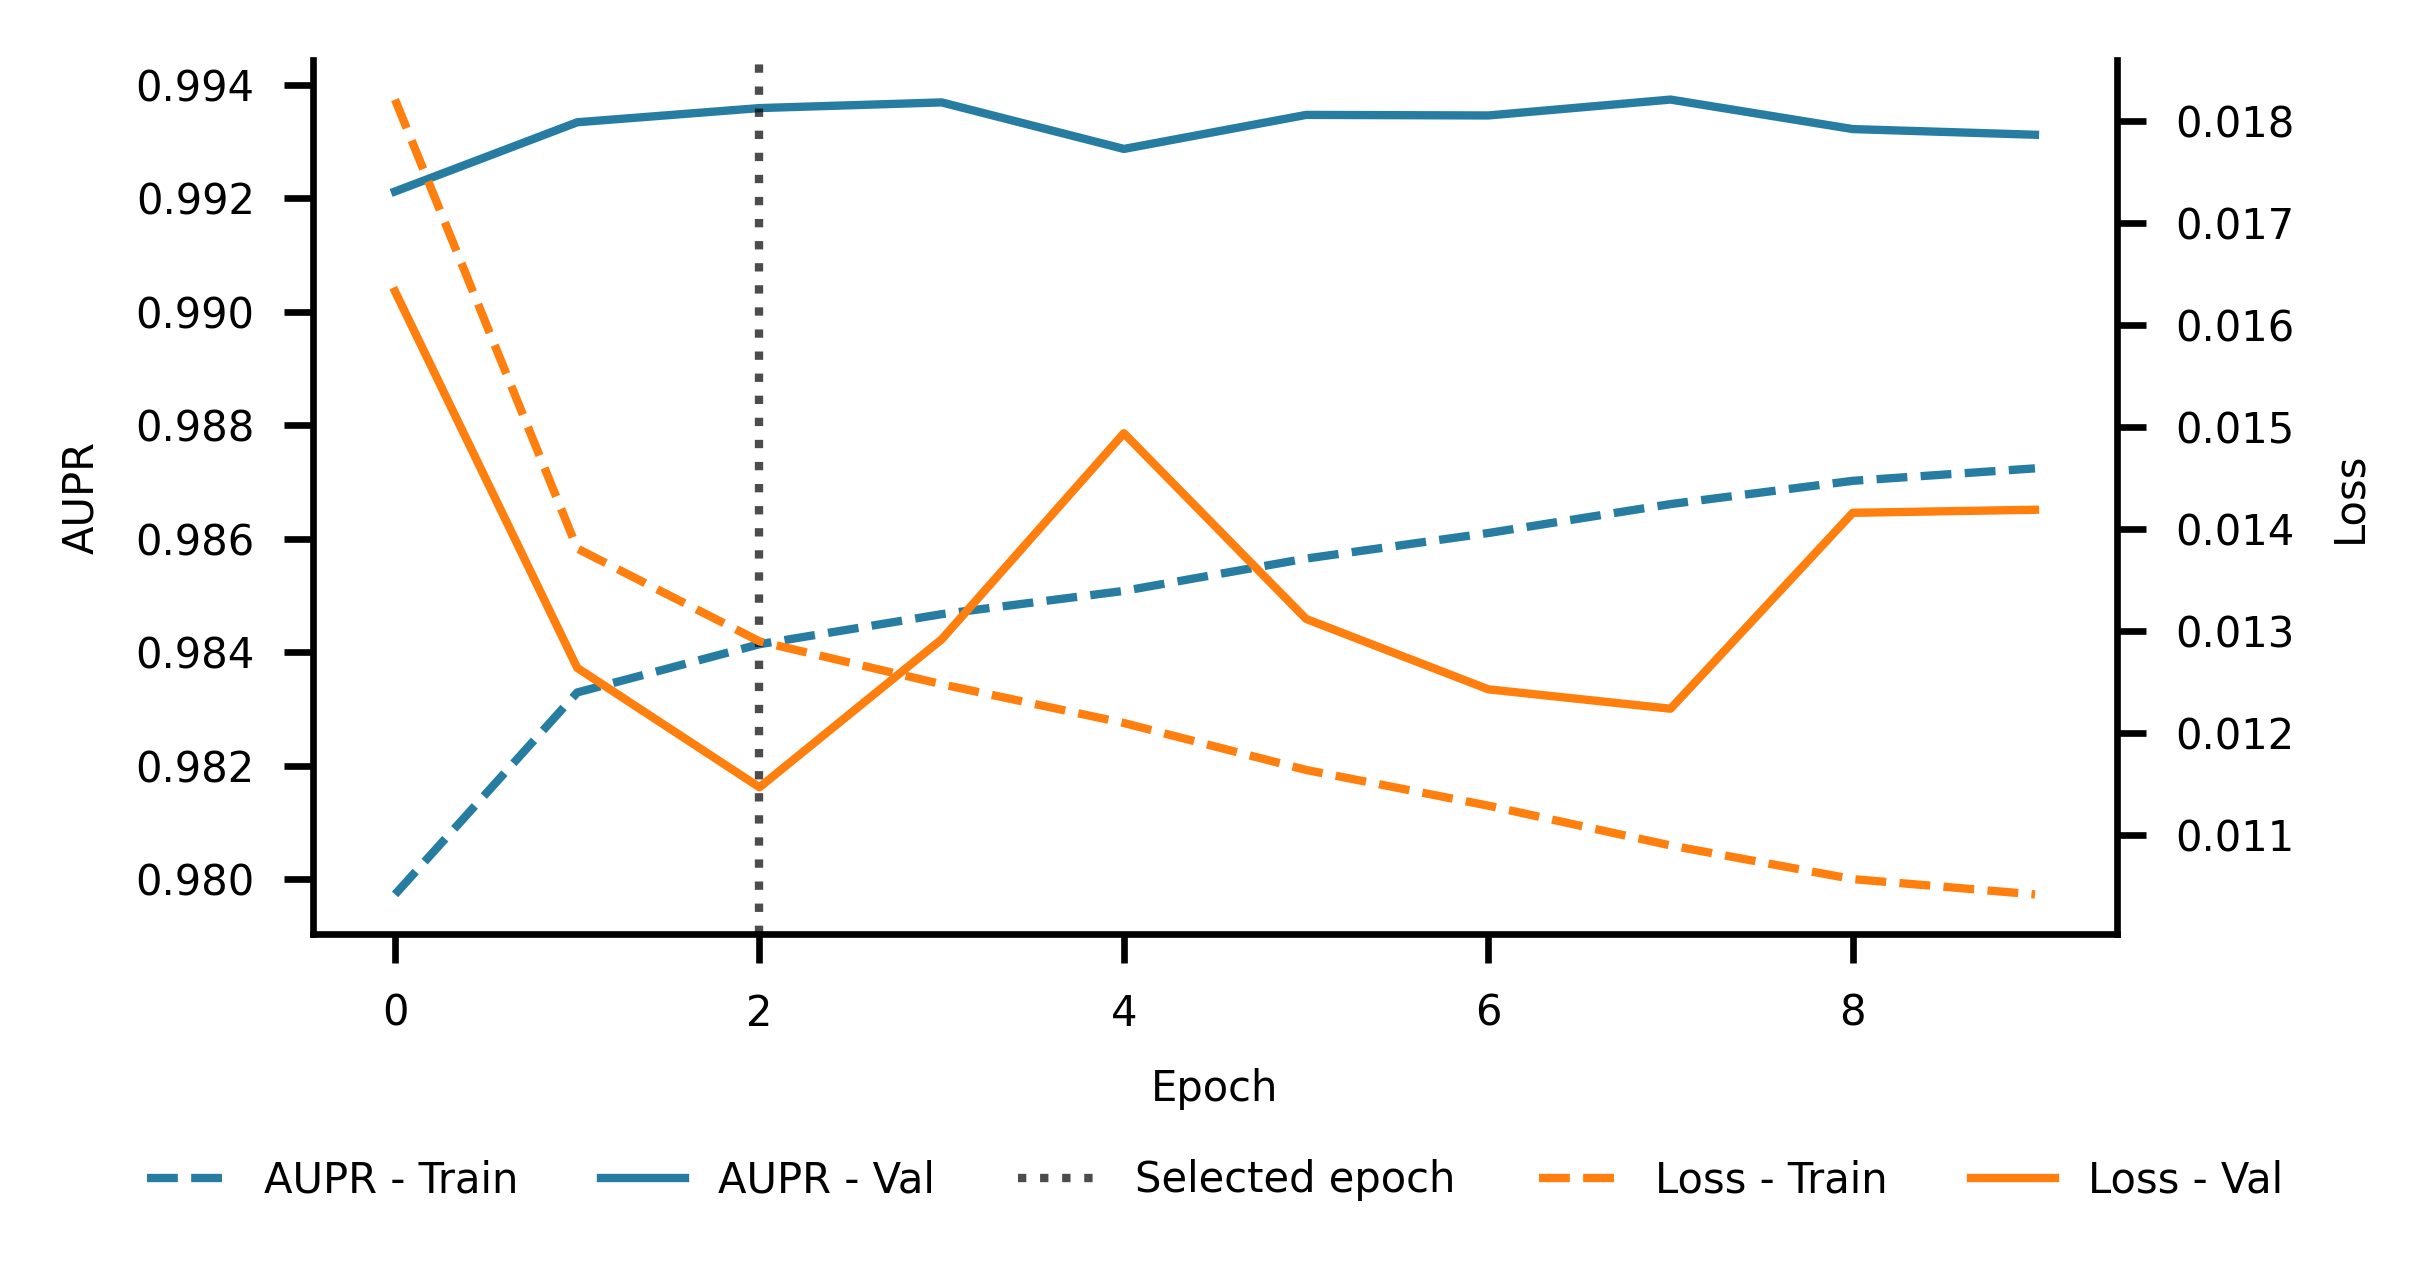

In [4]:
fs = 5
plt.rcParams.update({'font.size': fs, 'legend.fontsize':fs, 'figure.labelsize':fs})

fig, ax1 = plt.subplots(1, 1, figsize=(4, 2), dpi=600)
ax2 = ax1.twinx()

# AUPR
sns.lineplot(x="Epoch", y="Train weighted AP", data=training_stats, ax=ax1, color="#277DA1", label="AUPR - Train", linewidth=1, linestyle="--")
sns.lineplot(x="Epoch", y="Val weighted AP", data=training_stats, ax=ax1, color="#277DA1", label="AUPR - Val", linewidth=1, linestyle="-")

# Loss
sns.lineplot(x="Epoch", y="Train loss", data=training_stats, ax=ax2, color="#FF7F0E", label="Loss - Train", linewidth=1, linestyle="--")
sns.lineplot(x="Epoch", y="Val loss", data=training_stats, ax=ax2, color="#FF7F0E", label="Loss - Val", linewidth=1, linestyle="-")

# Relabeling
ax1.set_ylabel("AUPR")
ax2.set_ylabel("Loss")

# Changing spine visibility
for spine in ax1.spines.values():
    spine.set_visible(False)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax1.spines['left'].set_visible(True)   
ax1.spines['bottom'].set_visible(True) 
ax2.spines['right'].set_visible(True)

# Adding vertical line
ax1.axvline(x=2, color='black', linestyle=':', linewidth=1, label='Selected epoch', alpha=0.7)

# Handling legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc='lower center', 
           fontsize=fs, frameon=False, ncols=5, bbox_to_anchor=(.5, -0.02))
ax1.legend_.remove()
ax2.legend_.remove()

plt.tight_layout()

plt.tight_layout(rect=(0,0.05,1,1)) # (left, bottom, right, top)
plt.savefig("SPAPER_TrainingCurves.png")
plt.show()

